# 📰 Fake News Detection

## 📌 Problem Statement
Build a machine learning model to classify news articles as **FAKE** or **REAL** using Natural Language Processing.

## 🎯 Objectives
- Load and merge fake/real news datasets
- Perform exploratory data analysis
- Clean and preprocess text
- Convert text into numerical features using TF-IDF
- Train machine learning classifier
- Evaluate model performance
- Build custom fake news prediction demo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

plt.style.use('ggplot')

In [2]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SivaGuduri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SivaGuduri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 📂 Load Dataset

In [3]:
fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print(fake_df.shape)
print(true_df.shape)

(23481, 4)
(21417, 4)


In [4]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [5]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## 🏷️ Label and Merge Dataset

In [7]:
fake_df['label'] = 'FAKE'
true_df['label'] = 'REAL'

df = pd.concat([fake_df, true_df], ignore_index=True)

df.shape

(44898, 5)

## Shuffle dataset

In [8]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",FAKE
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",FAKE
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",REAL


## Check class balance

In [9]:
df['label'].value_counts()

label
FAKE    23481
REAL    21417
Name: count, dtype: int64

## class distribution chart

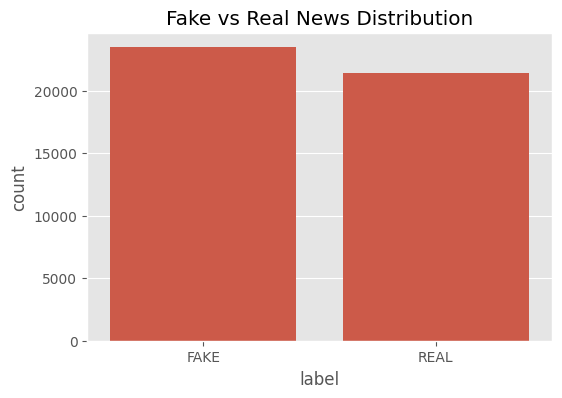

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Fake vs Real News Distribution')
plt.show()

## 📝 Feature Engineering
Combine title and article text

In [11]:
df['content'] = df['title'] + " " + df['text']

df[['title', 'content', 'label']].head()

,title,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...,FAKE
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...,REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...,REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Le...,FAKE
4,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...,REAL


## 🧹 Text Preprocessing
Cleaning article text for machine learning.

In [12]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()

    tokens = word_tokenize(text)

    cleaned_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]

    return " ".join(cleaned_tokens)

## Apply preprocessing

In [15]:
df['clean_content'] = df['content'].apply(preprocess_text)

In [16]:
df[['content', 'clean_content', 'label']].head()

,content,clean_content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls circuit court committed coup é...,FAKE
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon national security cou...,REAL
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects lift jones act shipping re...,REAL
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...,FAKE
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads scotland reopen golf resort...,REAL


## TF-IDF Vectorization

In [17]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=10000)

X = vectorizer.fit_transform(df['clean_content'])
y = df['label']

print(X.shape)

(44898, 10000)


## Train Test Split

In [18]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(35918, 10000)
(8980, 10000)


## Model Training

In [19]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Predictions and Accuracy

In [20]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9846325167037862


## Confusion Matrix

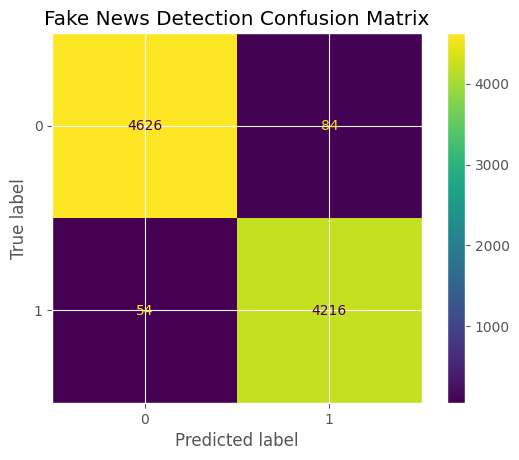

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Fake News Detection Confusion Matrix")
plt.show()

## Classification Report

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99      4710
        REAL       0.98      0.99      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



## Custom Prediction Function

In [23]:
def predict_news(news_text):
    cleaned = preprocess_text(news_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == "FAKE":
        return "🚨 Fake News"
    else:
        return "✅ Real News"

In [24]:
sample = """
Breaking: Scientists confirm drinking enough water improves health.
"""

print(predict_news(sample))

🚨 Fake News


## Fake News Word Cloud

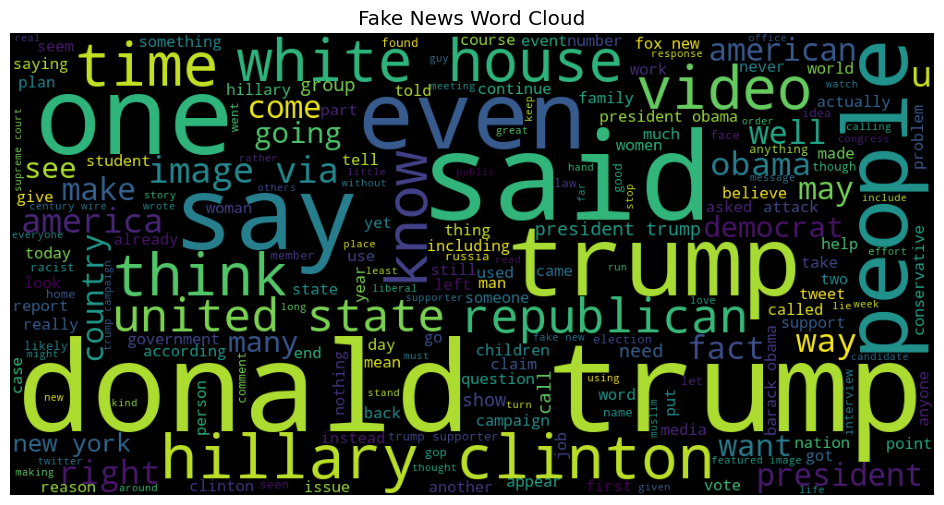

In [25]:
fake_text = " ".join(df[df['label'] == 'FAKE']['clean_content'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black'
).generate(fake_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Fake News Word Cloud')
plt.show()

## Real News Word Cloud

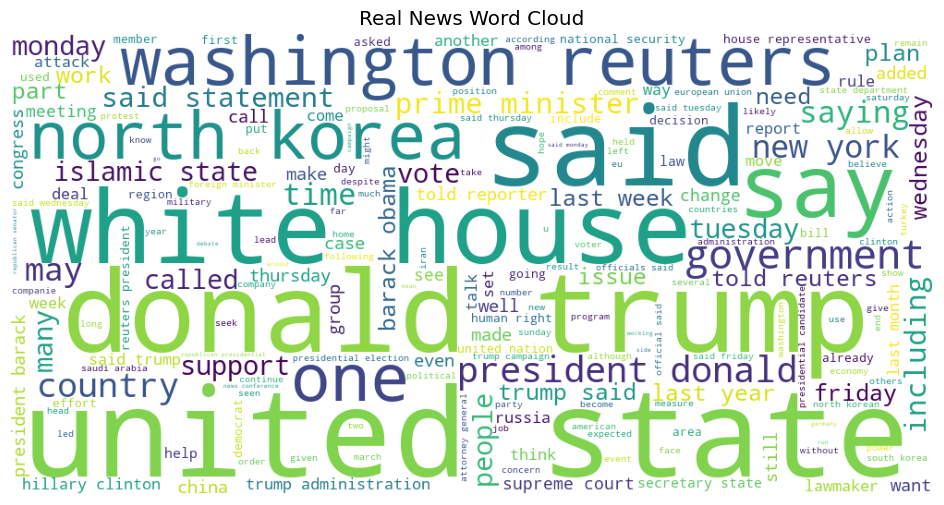

In [26]:
real_text = " ".join(df[df['label'] == 'REAL']['clean_content'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(real_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Real News Word Cloud')
plt.show()